In [1]:
import sys

sys.path.append("..")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

from src.data_pipeline import build_air_quality_features

# Run pipeline
df_feat = build_air_quality_features(
    "../data/raw/city_day.csv", target_city="Delhi"
)
print("Engineered DataFrame shape:", df_feat.shape)
df_feat.head(3)

c:\Users\HP\Documents\P_jects\air_quality\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Engineered DataFrame shape: (1213, 40)


,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,CO_lag3,CO_lag7,PM2.5_roll_mean_7,PM2.5_roll_std_7,PM2.5_roll_mean_14,NO2_roll_mean_7,NO2_roll_std_7,NO2_roll_mean_14,Target_PM25_t1,Target_NO2_t1
0,2015-01-15,Delhi,166.19,283.93,47.91,56.70,79.73,124.64,10.81,6.94,...,9.30,11.01,204.628571,20.998812,191.776429,43.880000,3.130016,39.753571,174.98,49.41
1,2015-01-16,Delhi,174.98,309.99,42.33,49.41,70.60,136.40,11.46,4.69,...,11.52,11.09,195.527143,22.002755,181.274286,45.814286,5.721681,41.204286,196.46,53.04
2,2015-01-17,Delhi,196.46,356.20,42.18,53.04,80.18,125.49,8.87,5.13,...,10.32,9.70,191.715714,23.049265,180.474286,47.364286,4.828954,42.385714,201.51,53.77


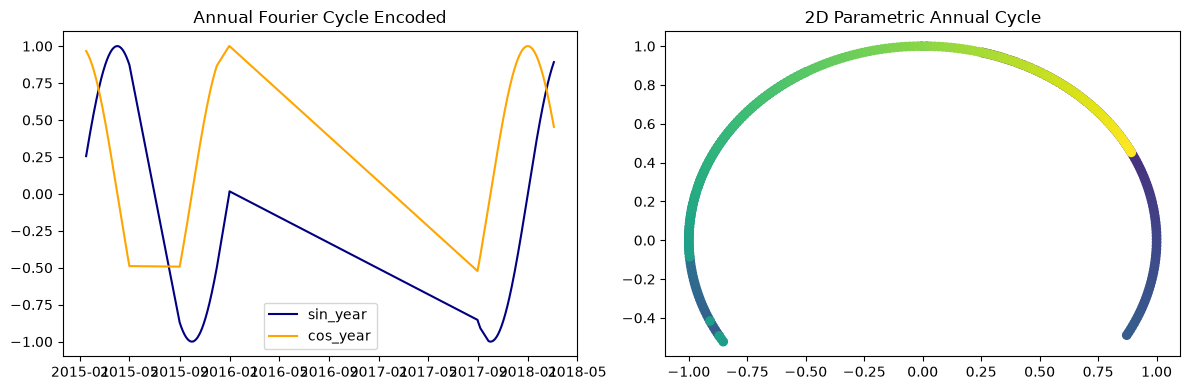

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(
    df_feat["Date"][:365],
    df_feat["sin_year"][:365],
    label="sin_year",
    color="navy",
)
ax[0].plot(
    df_feat["Date"][:365],
    df_feat["cos_year"][:365],
    label="cos_year",
    color="orange",
)
ax[0].set_title("Annual Fourier Cycle Encoded")
ax[0].legend()

ax[1].scatter(
    df_feat["sin_year"][:365],
    df_feat["cos_year"][:365],
    c=df_feat.index[:365],
    cmap="viridis",
)
ax[1].set_title("2D Parametric Annual Cycle")
plt.tight_layout()
plt.show()

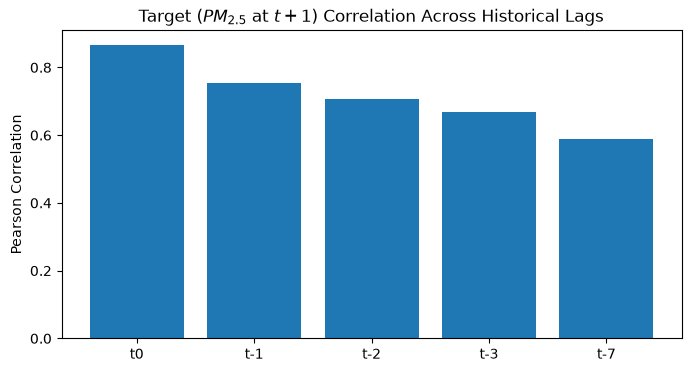

In [3]:
lags = [f"PM2.5_lag{i}" for i in [1, 2, 3, 7]]
corrs = [
    df_feat["Target_PM25_t1"].corr(df_feat[col])
    for col in ["PM2.5"] + lags
]

plt.figure(figsize=(8, 4))
plt.bar(["t0", "t-1", "t-2", "t-3", "t-7"], corrs, color="#1f77b4")
plt.title("Target ($PM_{2.5}$ at $t+1$) Correlation Across Historical Lags")
plt.ylabel("Pearson Correlation")
plt.show()

In [4]:
df_feat.to_csv("../data/processed/delhi_featured.csv", index=False)
print("Saved features to data/processed/delhi_featured.csv")

Saved features to data/processed/delhi_featured.csv
